# Environment

In [1]:
import sys
from pathlib import Path
import sqlite3
module_path = Path("../01_Functions_classes_and_variables").resolve()
sys.path.append(str(module_path))

from simulation_data_functions import *
from data_exploration_functions import *

import matplotlib.pyplot as plt
from spreg import ML_Lag
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML

from esda.moran import Moran

from sklearn.ensemble import RandomForestRegressor
from causalml.inference.meta import BaseSRegressor
from econml.dml import DML, LinearDML, SparseLinearDML, CausalForestDML
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import PolynomialFeatures

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

# Simulating data

## Single df

### Creating

In [2]:
gdf_output = return_spatial_geo_df(n_x = 40,  
    n_y = 20,    
    spacing = 100, 

    treated_scope_x_start = 10,
    treated_scope_x_end = 24,
    treated_scope_y_start = 7,
    treated_scope_y_end = 13,

    ATT_target = 1.5,

    y_spatial_autocorelation_scope_x_start = 3,
    y_spatial_autocorelation_scope_x_end = 25,
    y_spatial_autocorelation_scope_y_start = 4,
    y_spatial_autocorelation_scope_y_end = 11,

    rho = 0.15,

    spatial_confounder_scope_x_start = 12,
    spatial_confounder_scope_x_end = 32,
    spatial_confounder_scope_y_start = 2,
    spatial_confounder_scope_y_end = 18,
    

    lambda_cs = 0.2,
    max_treatment_spillover_distance = 400,
    understimated_treatment_spillover_distance=300,
    overestimated_treatment_spillover_distance=500,
    
    logistic_distance_decay = True,

    nonspatial_confounders_contribution_to_Y=1.0,
    spatial_confounder_contribution_to_Y=0.7,
    
    epsilon_distribution_mean = 0.025,
    epsilon_distribution_standard_error = 0.2)

#### Numerical checks

In [3]:
gdf_output.columns.tolist()

['unit_id',
 'geometry',
 'x',
 'y',
 'T',
 'propensity',
 'T_tot',
 'T_tot_cat',
 'T_tot_cat_underestim',
 'T_tot_cat_overerestim',
 'ODR_1',
 'ODR_2',
 'ODR_3',
 'ODR_4',
 'ODR_5',
 'C1',
 'C2',
 'C3',
 'Cs',
 'tau',
 'tau_base',
 'spill',
 'distance_to_treatment',
 'decay',
 'Y',
 'Y_ns']

In [4]:
gdf_output[gdf_output['ODR_4']!=0][['unit_id','geometry', 'T_tot','T_tot_cat','T_tot_cat_underestim','T_tot_cat_overerestim', 'ODR_4']]

,unit_id,geometry,T_tot,T_tot_cat,T_tot_cat_underestim,T_tot_cat_overerestim,ODR_4
127,1127,POINT (600 700),1,treated_outer_ring4,control,treated_outer_ring4,1
128,1128,POINT (600 800),1,treated_outer_ring4,control,treated_outer_ring4,1
129,1129,POINT (600 900),1,treated_outer_ring4,control,treated_outer_ring4,1
130,1130,POINT (600 1000),1,treated_outer_ring4,control,treated_outer_ring4,1
131,1131,POINT (600 1100),1,treated_outer_ring4,control,treated_outer_ring4,1
132,1132,POINT (600 1200),1,treated_outer_ring4,control,treated_outer_ring4,1
133,1133,POINT (600 1300),1,treated_outer_ring4,control,treated_outer_ring4,1
145,1145,POINT (700 500),1,treated_outer_ring4,control,treated_outer_ring4,1
146,1146,POINT (700 600),1,treated_outer_ring4,control,treated_outer_ring4,1
154,1154,POINT (700 1400),1,treated_outer_ring4,control,treated_outer_ring4,1


In [5]:
gdf_output['spill'].unique()

array([0.        , 0.00669285, 0.01774272, 0.0518728 , 0.07585818,
       0.11194084, 0.35659586, 0.5       , 0.8122148 , 0.92414182,
       1.        ])

In [6]:
gdf_output[(gdf_output['T_tot']!=0)
            #&(gdf_output2['T']!=0)
            ]['tau'].mean()

np.float64(0.7514425912425597)

In [7]:
gdf_output[(gdf_output['T_tot']!=0)
            &(gdf_output['T']!=0)
            ]['tau'].mean()

np.float64(1.5)

In [8]:
gdf_output[gdf_output['T']==1]

,unit_id,geometry,x,y,T,propensity,T_tot,T_tot_cat,T_tot_cat_underestim,T_tot_cat_overerestim,...,C2,C3,Cs,tau,tau_base,spill,distance_to_treatment,decay,Y,Y_ns
207,1207,POINT (1000 700),1000,700,1,0.248876,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,0.049355,-1.121680,-0.062029,1.487371,1.487371,1.0,0.0,1.0,1.503873,1.294475
208,1208,POINT (1000 800),1000,800,1,-0.317011,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,0.111317,-1.259154,0.107704,1.302796,1.302796,1.0,0.0,1.0,1.386197,1.075233
209,1209,POINT (1000 900),1000,900,1,0.126002,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,-0.350072,-1.142462,-0.685990,1.708135,1.708135,1.0,0.0,1.0,1.991924,1.643555
210,1210,POINT (1000 1000),1000,1000,1,0.696214,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,-1.555512,1.707988,-0.049215,1.347436,1.347436,1.0,0.0,1.0,2.467793,2.274851
211,1211,POINT (1000 1100),1000,1100,1,-1.958148,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,1.031061,-1.626359,-2.432798,1.346726,1.346726,1.0,0.0,1.0,-0.282842,-0.750015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489,1489,POINT (2400 900),2400,900,1,0.838513,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,2.011060,0.576658,0.053723,2.064301,2.064301,1.0,0.0,1.0,2.977359,2.824991
490,1490,POINT (2400 1000),2400,1000,1,-0.453307,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,-0.763856,-0.481023,0.589186,0.537590,0.537590,1.0,0.0,1.0,-0.332389,-0.627905
491,1491,POINT (2400 1100),2400,1100,1,2.472818,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,-0.712896,0.623303,0.376350,1.975567,1.975567,1.0,0.0,1.0,3.918498,3.787593
492,1492,POINT (2400 1200),2400,1200,1,1.079035,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,0.497964,1.613634,1.100288,1.013083,1.013083,1.0,0.0,1.0,1.717113,1.717113


In [9]:
gdf_output.isna().any().any()

np.False_

In [10]:
coords = np.array(list(zip(gdf_output["x"], gdf_output["y"])))

W = DistanceBand(coords, threshold=101, binary=True, silence_warnings=True)
W.transform = "R" 
moran_I_y= Moran(gdf_output['Y'], W)
[f'Moran I: {moran_I_y.I:.4f}',  f'p-value simulated: {moran_I_y.p_sim:.4f}']

['Moran I: 0.2658', 'p-value simulated: 0.0010']

#### Visual checks

In [11]:
gdf_output3 = gdf_output.copy()
gdf_output3['spill2'] = gdf_output3['spill'] + 0.5

<Axes: >

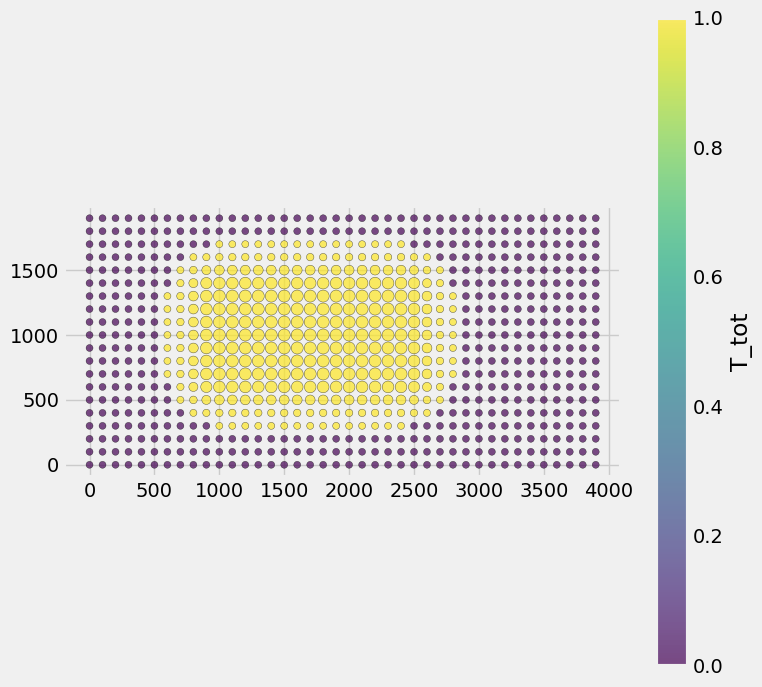

In [12]:
plot_gdf_points(gdf_output3, size_col='spill2',
    color_col='T_tot')

<Axes: >

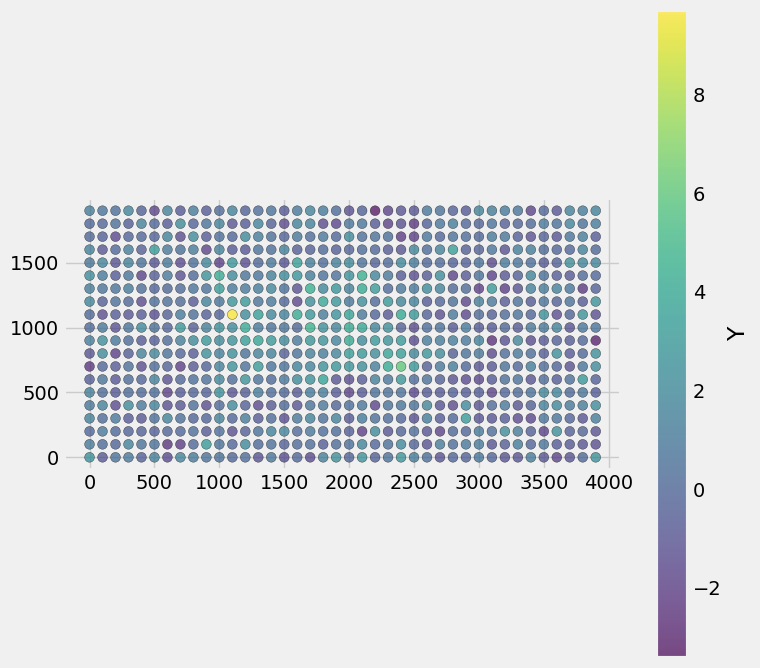

In [13]:
plot_gdf_points(gdf_output, #size_col='Y',
    color_col='Y')

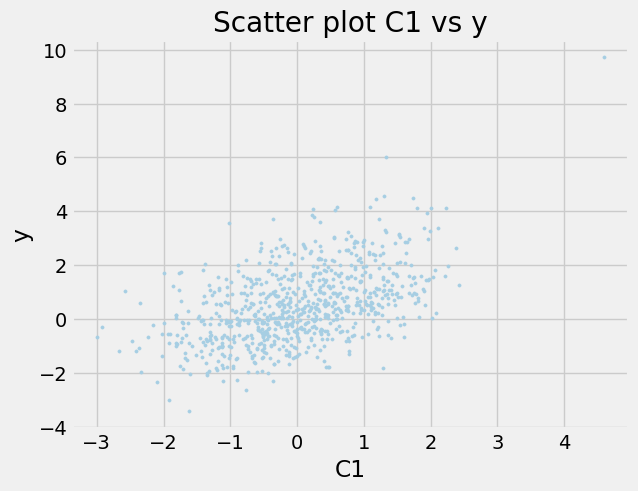

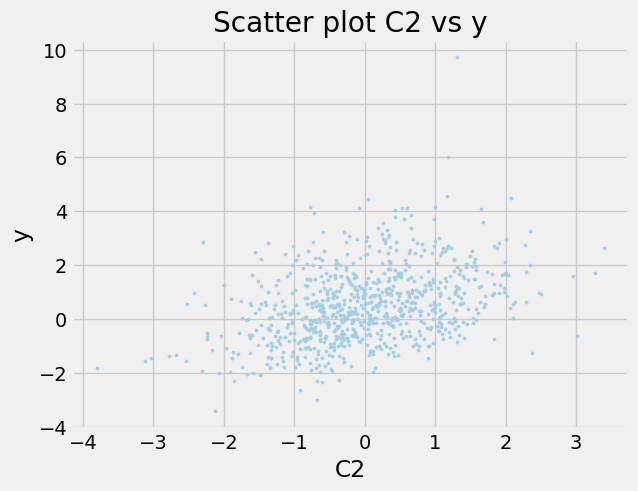

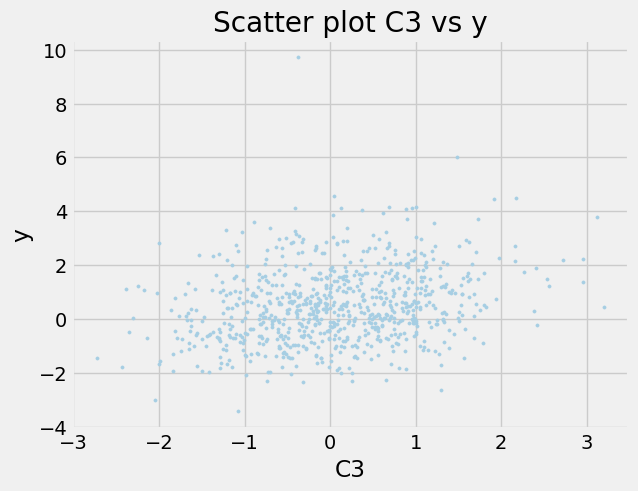

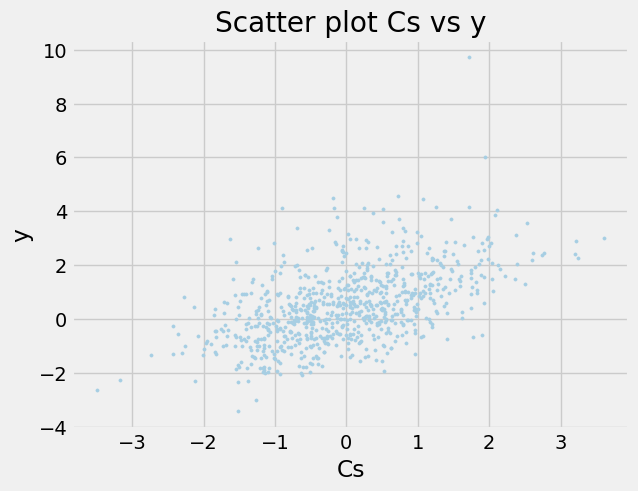

In [14]:
for i in ['C1','C2','C3','Cs']:
    gdf_output.plot.scatter(x=i, y="Y", s=5)
    plt.xlabel(i)
    plt.ylabel("y")
    plt.title(f"Scatter plot {i} vs y")
    plt.show()

#### Modelling checks

##### Data

In [15]:
X1 = gdf_output[["C1","C2",
         #"C3","Cs",
         'T'
         ]].values
X = gdf_output[["C1","C2",
         #"C3","Cs"
         ]].values
y = gdf_output["Y"].values.reshape(-1,1)
T = gdf_output["T"].values
T_tot = gdf_output["T_tot"].values
Xdf = gdf_output[["C1","C2",'T',
         #"C3","Cs"
         ]]
Xdf2 = gdf_output[["C1","C2",'T_tot',
         #"C3","Cs"
         ]]
X_l = sm.add_constant(Xdf)
X_l2 = sm.add_constant(Xdf2)
y_l = gdf_output["Y_ns"]
Y = gdf_output['Y'].values

X_logit = sm.add_constant(X)

In [16]:
gdf_output4 = gdf_output.copy()
gdf_output4['treated'] = 'control'
gdf_output4.loc[(gdf_output4['spill'] == 1),'treated'] = 'inner_ring'
gdf_output4.loc[(gdf_output4['spill'] <= 0.924143)& (gdf_output4['spill'] >= 0.812214),'treated'] = 'outer_ring1'
gdf_output4.loc[(gdf_output4['spill'] <= 0.500001)& (gdf_output4['spill'] >= 0.356595),'treated'] = 'outer_ring2'
gdf_output4.loc[(gdf_output4['spill'] <= 0.111942)& (gdf_output4['spill'] >= 0.075857),'treated'] = 'outer_ring3'
gdf_output4.loc[(gdf_output4['spill'] <= 0.017744)& (gdf_output4['spill'] >= 0.006692),'treated'] = 'outer_ring4'
df_encoded = pd.get_dummies(gdf_output4, columns=['treated'], dtype=int)
T_mult = df_encoded[['treated_inner_ring',
    'treated_outer_ring1',
    'treated_outer_ring2',
    'treated_outer_ring3',
    'treated_outer_ring4']].to_numpy()
T_M= gdf_output4['treated'].values
T_M= T_M.astype(str)

##### Logit for T

In [17]:
logit_model = sm.Logit(T, X_logit)
logit_res = logit_model.fit()

print(logit_res.summary())

Optimization terminated successfully.
         Current function value: 0.386946
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  800
Model:                          Logit   Df Residuals:                      797
Method:                           MLE   Df Model:                            2
Date:                Sun, 17 May 2026   Pseudo R-squ.:                0.004656
Time:                        15:57:15   Log-Likelihood:                -309.56
converged:                       True   LL-Null:                       -311.00
Covariance Type:            nonrobust   LLR p-value:                    0.2351
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.9058      0.106    -17.953      0.000      -2.114      -1.698
x1             0.1774      0.

##### Cross sectional linear difference in differences 

In [18]:
model = sm.OLS(y_l, X_l)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   Y_ns   R-squared:                       0.554
Model:                            OLS   Adj. R-squared:                  0.552
Method:                 Least Squares   F-statistic:                     329.6
Date:                Sun, 17 May 2026   Prob (F-statistic):          4.47e-139
Time:                        15:57:15   Log-Likelihood:                -1043.1
No. Observations:                 800   AIC:                             2094.
Df Residuals:                     796   BIC:                             2113.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2417      0.034      7.130      0.0

In [19]:
model = sm.OLS(y_l, X_l2)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   Y_ns   R-squared:                       0.474
Model:                            OLS   Adj. R-squared:                  0.472
Method:                 Least Squares   F-statistic:                     238.7
Date:                Sun, 17 May 2026   Prob (F-statistic):          1.86e-110
Time:                        15:57:16   Log-Likelihood:                -1109.5
No. Observations:                 800   AIC:                             2227.
Df Residuals:                     796   BIC:                             2246.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1794      0.044      4.075      0.0

##### Cross sectional difference in differences with spatial lag of Y

In [20]:
model_sdm = ML_Lag(
    y,
    X1,
    w=W,              
    slx_lags=1,       
    name_y="Y",
    name_x=["C1","C2", 'T'#,"C3","Cs"
            ]
)

print(model_sdm.summary)

ML_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG WITH SLX - SPATIAL DURBIN MODEL (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :           Y                Number of Observations:         800
Mean dependent var  :      0.4961                Number of Variables   :           8
S.D. dependent var  :      1.3752                Degrees of Freedom    :         792
Pseudo R-squared    :      0.5972
Spatial Pseudo R-squared:  0.5908
Log likelihood      :  -1027.8124
Sigma-square ML     :      0.7608                Akaike info criterion :    2071.625
S.E of regression   :      0.8722                Schwarz criterion     :    2109.102

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-----

##### Basic causal forest

###### For T

In [21]:
forest_Y = RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42)
forest_Y.fit(X, Y)

forest_T = RandomForestRegressor(n_estimators=180, max_depth=10, random_state=42)
forest_T.fit(X, T)

cf = CausalForestDML(model_y=forest_Y, model_t=forest_T, random_state=42)
cf.fit(Y, T, X=X)
tau_hat = cf.effect(X)



ate = tau_hat.mean()
se_ate = tau_hat.std(ddof=1) / np.sqrt(len(tau_hat))

ci_low_ate, ci_high_ate = ate - 1.96 * se_ate, ate + 1.96 * se_ate
gdf_rf_compare = gdf_output[['unit_id',	'geometry',	'T', 'tau']].copy()
gdf_rf_compare['tau_cf'] = tau_hat
gdf_rf_compare[gdf_rf_compare['T']==1]

,unit_id,geometry,T,tau,tau_cf
207,1207,POINT (1000 700),1,1.487371,1.614409
208,1208,POINT (1000 800),1,1.302796,1.175432
209,1209,POINT (1000 900),1,1.708135,1.750634
210,1210,POINT (1000 1000),1,1.347436,1.509316
211,1211,POINT (1000 1100),1,1.346726,0.940755
...,...,...,...,...,...
489,1489,POINT (2400 900),1,2.064301,1.762323
490,1490,POINT (2400 1000),1,0.537590,1.124732
491,1491,POINT (2400 1100),1,1.975567,1.924316
492,1492,POINT (2400 1200),1,1.013083,1.419717


In [22]:
ci_low_ate, ate, ci_high_ate

(np.float64(1.6171389023002807),
 np.float64(1.6463694577695458),
 np.float64(1.675600013238811))

In [23]:
gdf_rf_compare[gdf_rf_compare['T']==1]['tau_cf'].mean()

np.float64(1.6563615483043799)

###### For T tot

In [24]:
forest_Y = RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42)
forest_Y.fit(X, Y)

forest_T = RandomForestRegressor(n_estimators=180, max_depth=10, random_state=42)
forest_T.fit(X, T_tot)

cf = CausalForestDML(model_y=forest_Y, model_t=forest_T, random_state=42)
cf.fit(Y, T_tot, X=X)
tau_hat = cf.effect(X)



ate = tau_hat.mean()
se_ate = tau_hat.std(ddof=1) / np.sqrt(len(tau_hat))

ci_low_ate, ci_high_ate = ate - 1.96 * se_ate, ate + 1.96 * se_ate
gdf_rf_compare = gdf_output[['unit_id',	'geometry',	'T_tot', 'tau', 'tau_base']].copy()
gdf_rf_compare['tau_cf'] = tau_hat
gdf_rf_compare[gdf_rf_compare['T_tot']==1]

,unit_id,geometry,T_tot,tau,tau_base,tau_cf
127,1127,POINT (600 700),1,0.003102,0.463439,0.587206
128,1128,POINT (600 800),1,0.010075,1.505309,0.891419
129,1129,POINT (600 900),1,0.006590,0.984610,0.665858
130,1130,POINT (600 1000),1,0.004240,0.633555,0.354301
131,1131,POINT (600 1100),1,0.006765,1.010854,0.608731
...,...,...,...,...,...,...
569,1569,POINT (2800 900),1,0.009804,1.464920,1.135898
570,1570,POINT (2800 1000),1,0.002320,0.346568,0.707321
571,1571,POINT (2800 1100),1,0.008974,1.340811,1.040150
572,1572,POINT (2800 1200),1,0.005557,0.830231,0.365914


#### Multiple T DML

In [25]:
est = LinearDML(model_y=GradientBoostingRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                model_t=MultiOutputRegressor(GradientBoostingRegressor(n_estimators=100,
                                                                       max_depth=3,
                                                                       min_samples_leaf=20)),
                featurizer=PolynomialFeatures(degree=2, include_bias=False),
                cv=None)


In [26]:
est.fit(Y, T_mult, X=X, 
        #W=W
        )

In [27]:
te_pred = est.const_marginal_effect(X)
te_pred

array([[ 2.47807081,  1.80785551,  0.147198  , -0.30535916, -0.17621602],
       [ 2.04439271,  1.36876138,  1.18533935, -0.18526644, -0.07170043],
       [ 1.21365129,  0.61280625, -0.30340023,  0.0943891 ,  0.21164941],
       ...,
       [ 2.19200129,  1.551317  ,  0.15884972, -0.20390365, -0.15683768],
       [ 1.25228073,  0.51686131, -0.27088803,  0.08527653,  0.20544505],
       [ 1.96355756,  1.11895967,  0.11396021, -0.23423946, -0.07133406]],
      shape=(800, 5))

In [28]:
est2 = CausalForestDML(model_y=GradientBoostingRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                       model_t=MultiOutputRegressor(GradientBoostingRegressor(n_estimators=100,
                                                                              max_depth=3,
                                                                              min_samples_leaf=20)),
                       cv=None,
                       criterion='mse', n_estimators=1000,
                       min_samples_leaf=10,
                       min_impurity_decrease=0.001,
                       random_state=123)

est2.tune(Y, T_mult, X=X, 
          #W=W
          )
est2.fit(Y, T_mult, X=X, 
         #W=W
         )

In [29]:
te_pred2 = est2.const_marginal_effect(X)
te_pred2

array([[ 2.17028595,  1.41341933,  0.32348231, -0.36136755, -0.21015246],
       [ 1.88668759,  1.3729801 ,  0.46250196, -0.25679951, -0.15917589],
       [ 1.55672815,  0.95205788, -0.09089682, -0.07732536,  0.05191782],
       ...,
       [ 2.06298383,  1.3918082 ,  0.36964427, -0.18732632, -0.12287894],
       [ 1.51486558,  0.79015423, -0.18801234, -0.12588568,  0.09799208],
       [ 2.03001127,  1.40075438,  0.16771609, -0.33699403, -0.17047184]],
      shape=(800, 5))

#### S learner with multiple treatments

In [30]:
RF_s_learner = BaseSRegressor(RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42), control_name = 'control')
ate, lb, ub = RF_s_learner.estimate_ate(X, T_M, Y, return_ci = True)
ite = RF_s_learner.fit_predict(X, T_M, Y)
ITE_df = pd.DataFrame(ite).rename(columns = {0:'inner_ring', 1:'outer_ring1', 
                                             2:'outer_ring2', 3:'outer_ring3',
                                             4:'outer_ring4'})
ITE_df['treated'] = T_M
ITE_df['ITE_real'] = gdf_output4['tau']
ITE_df['Y'] = Y

In [31]:
ate, lb, ub

(array([ 1.73508621,  0.89149808,  0.03619254, -0.0107484 , -0.0072682 ]),
 array([ 1.62395822,  0.75210564, -0.07413917, -0.12785231, -0.10072094]),
 array([1.8462142 , 1.03089052, 0.14652425, 0.1063555 , 0.08618454]))

In [32]:
ITE_df['treated'].unique()

array(['control', 'outer_ring4', 'outer_ring3', 'outer_ring2',
       'outer_ring1', 'inner_ring'], dtype=object)

In [33]:
for i in ['outer_ring4', 'outer_ring3', 'outer_ring2', 'outer_ring1', 'inner_ring']:
    series_of_interest = ITE_df[ITE_df['treated']==i][i]
    att = series_of_interest.mean()
    se_att = (series_of_interest).std(ddof=1) / np.sqrt(len(series_of_interest))
    ci_low_att, ci_high_att = att - 1.96 * se_att, att + 1.96 * se_att
    print(i, 
          [ci_low_att, att, ci_high_att], 
          ITE_df[ITE_df['treated']==i]['ITE_real'].mean())

outer_ring4 [np.float64(-0.058456648446362544), np.float64(-0.02327483227486486), np.float64(0.01190698389663283)] 0.00934208558452958
outer_ring3 [np.float64(-0.06342719001748032), np.float64(-0.015868115037195926), np.float64(0.03169095994308846)] 0.08496407423973133
outer_ring2 [np.float64(-0.016770854891829244), np.float64(0.06242729359473725), np.float64(0.14162544208130373)] 0.5153033663708263
outer_ring1 [np.float64(0.6872292015599422), np.float64(0.9012101489524867), np.float64(1.1151910963450313)] 0.9570904468697957
inner_ring [np.float64(1.4867403953213312), np.float64(1.6388915943062081), np.float64(1.791042793291085)] 1.5


In [34]:
ITE_df

,inner_ring,outer_ring1,outer_ring2,outer_ring3,outer_ring4,treated,ITE_real,Y
0,0.830164,0.834839,-0.007570,-0.081014,-0.031338,control,0.0,2.458144
1,1.736050,0.939064,0.600540,-0.029886,-0.107518,control,0.0,1.007491
2,1.225251,0.188339,-0.076380,0.051142,0.011228,control,0.0,-0.053617
3,1.520932,0.533547,-0.034741,-0.070728,-0.162134,control,0.0,1.357190
4,0.843765,0.516679,-0.271464,-0.003451,-0.042506,control,0.0,0.849322
...,...,...,...,...,...,...,...,...
795,0.502039,0.292366,-0.127987,-0.037174,0.000000,control,0.0,1.701561
796,0.751473,0.496813,-0.024008,0.033634,0.018991,control,0.0,0.037931
797,3.215049,2.103903,0.003882,0.064731,0.032038,control,0.0,-0.617833
798,0.426238,-0.114308,-0.331217,-0.063718,0.017828,control,0.0,1.057580


In [35]:
ITE_df[ITE_df['treated']=='inner_ring']['ITE_real'].mean()

np.float64(1.5)

## Generating multiple df for simulations

### Data generation

In [ ]:
gdf_output = return_spatial_geo_df(n_x = 40,  
    n_y = 20,    
    spacing = 100, 

    treated_scope_x_start = 10,
    treated_scope_x_end = 24,
    treated_scope_y_start = 7,
    treated_scope_y_end = 13,

    ATT_target = 1.5,

    y_spatial_autocorelation_scope_x_start = 3,
    y_spatial_autocorelation_scope_x_end = 25,
    y_spatial_autocorelation_scope_y_start = 4,
    y_spatial_autocorelation_scope_y_end = 11,

    rho = 0.15,

    spatial_confounder_scope_x_start = 12,
    spatial_confounder_scope_x_end = 32,
    spatial_confounder_scope_y_start = 2,
    spatial_confounder_scope_y_end = 18,
    

    lambda_cs = 0.2,
    max_treatment_spillover_distance = 400,
    understimated_treatment_spillover_distance=300,
    overestimated_treatment_spillover_distance=500,
    
    logistic_distance_decay = True,

    nonspatial_confounders_contribution_to_Y=1.0,
    spatial_confounder_contribution_to_Y=0.7,
    
    epsilon_distribution_mean = 0.025,
    epsilon_distribution_standard_error = 0.2)

In [63]:
list_of_rhos = []
for i in np.arange(0.75, 0.000, -0.05):
    list_of_rhos.append(i)
len(list_of_rhos)

15

In [64]:
dict_of_output_gdf = {}
for i in list_of_rhos:
    single_gdf_output = return_spatial_geo_df(n_x = 40,  
        n_y = 20,    
        spacing = 100, 

        treated_scope_x_start = 10,
        treated_scope_x_end = 24,
        treated_scope_y_start = 7,
        treated_scope_y_end = 13,

        ATT_target = 1.5,

        y_spatial_autocorelation_scope_x_start = 3,
        y_spatial_autocorelation_scope_x_end = 25,
        y_spatial_autocorelation_scope_y_start = 4,
        y_spatial_autocorelation_scope_y_end = 11,

        rho = 0.15,

        spatial_confounder_scope_x_start = 12,
        spatial_confounder_scope_x_end = 32,
        spatial_confounder_scope_y_start = 2,
        spatial_confounder_scope_y_end = 18,
        

        lambda_cs = 0.2,
        max_treatment_spillover_distance = 400,
        understimated_treatment_spillover_distance=300,
        overestimated_treatment_spillover_distance=500,
        
        logistic_distance_decay = True,

        nonspatial_confounders_contribution_to_Y=1.0,
        spatial_confounder_contribution_to_Y=0.7,
        
        epsilon_distribution_mean = 0.025,
        epsilon_distribution_standard_error = 0.2)
    single_gdf_output2 = single_gdf_output.drop(columns = ['y', 'x']).copy()
    dict_of_output_gdf[f'gdf_rho_0_{str(i)[2:5]}'] = single_gdf_output2

In [72]:
len(['gdf_rho_0_75', 'gdf_rho_0_7', 'gdf_rho_0_649', 'gdf_rho_0_599', 'gdf_rho_0_549', 'gdf_rho_0_499', 'gdf_rho_0_449', 'gdf_rho_0_399', 'gdf_rho_0_349', 'gdf_rho_0_299', 'gdf_rho_0_249', 'gdf_rho_0_199', 'gdf_rho_0_149', 'gdf_rho_0_099', 'gdf_rho_0_049'])

15

In [71]:
dict_of_output_gdf.keys()

dict_keys(['gdf_rho_0_75', 'gdf_rho_0_7', 'gdf_rho_0_649', 'gdf_rho_0_599', 'gdf_rho_0_549', 'gdf_rho_0_499', 'gdf_rho_0_449', 'gdf_rho_0_399', 'gdf_rho_0_349', 'gdf_rho_0_299', 'gdf_rho_0_249', 'gdf_rho_0_199', 'gdf_rho_0_149', 'gdf_rho_0_099', 'gdf_rho_0_049'])

In [66]:
moran_I_y= Moran(dict_of_output_gdf['gdf_rho_0_024']['Y'], W)
[f'Moran I: {moran_I_y.I:.4f}',  f'p-value simulated: {moran_I_y.p_sim:.4f}']

KeyError: 'gdf_rho_0_024'

In [74]:
dict_of_output_gdf['gdf_rho_0_75'].columns.tolist()

['unit_id',
 'geometry',
 'T',
 'propensity',
 'T_tot',
 'T_tot_cat',
 'T_tot_cat_underestim',
 'T_tot_cat_overerestim',
 'ODR_1',
 'ODR_2',
 'ODR_3',
 'ODR_4',
 'ODR_5',
 'C1',
 'C2',
 'C3',
 'Cs',
 'tau',
 'tau_base',
 'spill',
 'distance_to_treatment',
 'decay',
 'Y',
 'Y_ns']

In [80]:
dict_of_output_gdf['gdf_rho_0_75']#[['T', 
# 'ODR_1',
#  'ODR_2',
#  'ODR_3',
#  'ODR_4',
#  'ODR_5',]]

,unit_id,geometry,T,propensity,T_tot,T_tot_cat,T_tot_cat_underestim,T_tot_cat_overerestim,ODR_1,ODR_2,...,C2,C3,Cs,tau,tau_base,spill,distance_to_treatment,decay,Y,Y_ns
0,1000,POINT (0 0),0,4.254438,0,control,control,control,0,0,...,1.372350,1.016700,1.060375,0.0,0.0,0.0,1220.655562,0.0,3.583302,3.583302
1,1001,POINT (0 100),0,2.048454,0,control,control,control,0,0,...,0.900955,-1.970727,1.532452,0.0,0.0,0.0,1166.190379,0.0,1.664774,1.664774
2,1002,POINT (0 200),0,1.078793,0,control,control,control,0,0,...,2.018252,-0.491111,0.265209,0.0,0.0,0.0,1118.033989,0.0,0.924681,0.924681
3,1003,POINT (0 300),0,-2.519299,0,control,control,control,0,0,...,0.207359,-1.439220,-1.973424,0.0,0.0,0.0,1077.032961,0.0,-1.424234,-1.424234
4,1004,POINT (0 400),0,1.401347,0,control,control,control,0,0,...,1.272138,-1.069532,0.568843,0.0,0.0,0.0,1044.030651,0.0,0.939380,0.939380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,1795,POINT (3900 1500),0,0.546255,0,control,control,control,0,0,...,0.089682,-0.034207,0.546066,0.0,0.0,0.0,1513.274595,0.0,0.515627,0.515627
796,1796,POINT (3900 1600),0,0.217175,0,control,control,control,0,0,...,-0.940505,-1.865176,0.224257,0.0,0.0,0.0,1529.705854,0.0,-0.243606,-0.243606
797,1797,POINT (3900 1700),0,-0.753369,0,control,control,control,0,0,...,-0.634399,-0.750518,0.720580,0.0,0.0,0.0,1552.417470,0.0,-0.990687,-0.990687
798,1798,POINT (3900 1800),0,1.541784,0,control,control,control,0,0,...,0.413491,0.080933,0.461412,0.0,0.0,0.0,1581.138830,0.0,0.898532,0.898532


In [78]:
temp_df[temp_df['ODR_1']!=0]

,T,ODR_1,ODR_2,ODR_3,ODR_4,ODR_5
187,0,1,0,0,0,0
188,0,1,0,0,0,0
189,0,1,0,0,0,0
190,0,1,0,0,0,0
191,0,1,0,0,0,0
192,0,1,0,0,0,0
193,0,1,0,0,0,0
206,0,1,0,0,0,0
214,0,1,0,0,0,0
226,0,1,0,0,0,0


### Data saving

In [58]:
repo_path_wndws = Path("../").resolve()
repo_path_unix = repo_path_wndws.as_posix() 
repo_path_r_string = repo_path_unix.replace("/", '\\')

In [59]:
conn = sqlite3.connect(repo_path_r_string + r'\03_simulated_data\simulated_data.sqlite')
cursor = conn.cursor()

In [60]:
repo_path_r_string

'C:\\Users\\andre\\Desktop\\IDS\\02_VS_code\\03_comparing_causal_ML_models_with_spatial_effects'

In [62]:
for k in dict_of_output_gdf.keys():
    dict_of_output_gdf[k].to_file(
        repo_path_r_string + r'\03_simulated_data\simulated_data.sqlite',
        layer=k,
        driver="SQLite",
        #spatialite=True,
        #if_exists="replace"
    )

PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\andre\\Desktop\\IDS\\02_VS_code\\03_comparing_causal_ML_models_with_spatial_effects\\03_simulated_data\\simulated_data.sqlite'

In [67]:
sqlite_path = repo_path_r_string + r"\03_simulated_data\simulated_data.sqlite"

for k, gdf in dict_of_output_gdf.items():

    gdf.to_file(
        sqlite_path,
        layer=k,
        driver="SQLite"
    )

In [ ]:
conn.close()